# Visual Test for DataLoader

This notebook provides a visual and step-by-step walkthrough for testing the data loading pipeline. It complements the automated `test_data_loader.py` script by showing images and explaining each stage of the process.

## 1. Setup

First, we import all necessary libraries and set the `KMP_DUPLICATE_LIB_OK` environment variable to prevent OpenMP conflicts.

In [1]:
import os
import sys
from pathlib import Path

# Add the parent directory (project root) to the system path.
# This allows the notebook to import modules like `data_loader`.
# This assumes the notebook kernel is running from the 'tests' directory.
sys.path.insert(0, '..')
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import shutil
from pathlib import Path
import zipfile
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt

# Project file imports
from data_loader import SegmentationDataset, build_dataloader
from resize import resize_dataset
from split import find_case_ids, split_case_ids, write_case_ids

print("Setup complete.")

Setup complete.


## 2. Unit Test with Fake Data

This section replicates the unit tests from `test_data_loader.py`. We will create a small, temporary dataset of fake NIfTI files to quickly test the core functionality of `SegmentationDataset` and `build_dataloader`.

In [2]:
# Define parameters for our fake dataset
test_dir = Path("./temp_test_data_notebook")
if test_dir.exists():
    shutil.rmtree(test_dir)
test_dir.mkdir(exist_ok=True)

num_samples = 5
img_shape = (64, 64, 32)
case_ids = []

print(f"Creating a fake dataset in: {test_dir.resolve()}")

# Create fake NIfTI files
for i in range(num_samples):
    case_id = f"case_{i:03d}"
    case_ids.append(case_id)

    img_data = np.random.rand(*img_shape).astype(np.float32)
    mask_data = (np.random.rand(*img_shape) > 0.5).astype(np.uint8)

    img_nii = nib.Nifti1Image(img_data, np.eye(4))
    mask_nii = nib.Nifti1Image(mask_data, np.eye(4))

    nib.save(img_nii, test_dir / f"{case_id}_img.nii")
    nib.save(mask_nii, test_dir / f"{case_id}_mask.nii")

# Create a split file that includes all our fake cases
split_file = test_dir / "test_split.txt"
split_file.write_text("\n".join(case_ids))

print(f"Successfully created {num_samples} fake image/mask pairs and a split file.")

Creating a fake dataset in: C:\Git\QMUL-EMS741-Extended-Projected-Group1\tests\temp_test_data_notebook
Successfully created 5 fake image/mask pairs and a split file.


### Test `SegmentationDataset` Initialization

Now, let's create an instance of our `SegmentationDataset` and check if it correctly finds and loads the sample information.

In [3]:
dataset = SegmentationDataset(data_dir=test_dir, split_file=split_file)
print(f"Dataset initialized successfully.")
print(f"Number of samples found: {len(dataset)}")

Dataset initialized successfully.
Number of samples found: 5


### Test `__getitem__` and Visualize a Sample

This is the main advantage of a notebook. We can retrieve a single item from the dataset and visualize it to confirm it looks correct. We'll grab the first sample and display a slice from the middle of the 3D volume.

Retrieved item for case: case_000
Image tensor shape: torch.Size([1, 64, 64, 32]) (C, H, W, D)
Mask tensor shape: torch.Size([64, 64, 32]) (H, W, D)


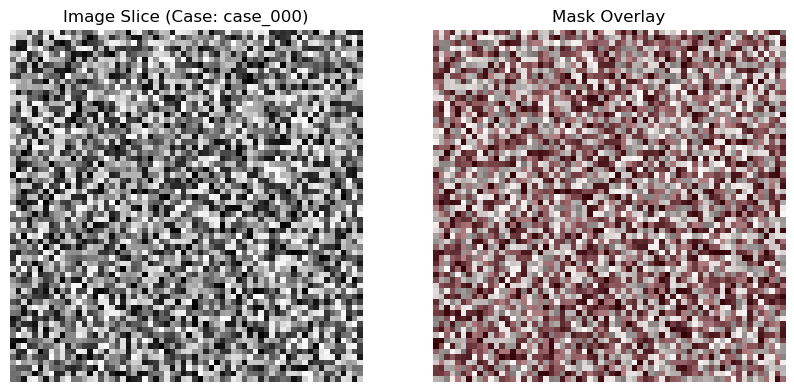

In [4]:
item = dataset[0]

print(f"Retrieved item for case: {item['case_id']}")
print(f"Image tensor shape: {item['image'].shape} (C, H, W, D)")
print(f"Mask tensor shape: {item['mask'].shape} (H, W, D)")

# Prepare for visualization
image_slice = item['image'][0, :, :, img_shape[2] // 2].numpy()
mask_slice = item['mask'][:, :, img_shape[2] // 2].numpy()

# Plot the image and mask slices
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image_slice, cmap='gray')
axs[0].set_title(f"Image Slice (Case: {item['case_id']})")
axs[0].axis('off')

axs[1].imshow(image_slice, cmap='gray') # Show image as background
axs[1].imshow(mask_slice, cmap='Reds', alpha=0.5) # Overlay mask
axs[1].set_title(f"Mask Overlay")
axs[1].axis('off')

plt.show()

### Test `build_dataloader`

Finally, let's test the `build_dataloader` function to ensure it can correctly batch the items from our dataset.

In [5]:
batch_size = 2
loader = build_dataloader(
    data_dir=test_dir,
    split_file=split_file,
    batch_size=batch_size,
    shuffle=False,
)

batch = next(iter(loader))

print(f"Successfully retrieved a batch of size: {batch_size}")
print(f"Batch image shape: {batch['image'].shape} (B, C, H, W, D)")
print(f"Batch mask shape: {batch['mask'].shape} (B, H, W, D)")
print(f"Case IDs in batch: {batch['case_id']}")

Successfully retrieved a batch of size: 2
Batch image shape: torch.Size([2, 1, 64, 64, 32]) (B, C, H, W, D)
Batch mask shape: torch.Size([2, 64, 64, 32]) (B, H, W, D)
Case IDs in batch: ['case_000', 'case_001']


### Clean Up Fake Data

In [6]:
shutil.rmtree(test_dir)
print(f"Successfully removed temporary directory: {test_dir}")

Successfully removed temporary directory: temp_test_data_notebook


## 3. Integration Test with Real Data (`data.zip`)

This section runs the full pipeline: unzipping, resizing, splitting, and loading. It's a more comprehensive test but takes longer to run. 

**Note:** This will only run if `data.zip` is present in the project's root directory.

In [7]:
integration_test_dir = Path("./temp_integration_test_data_notebook")
data_zip_path = Path("../data.zip")

if not data_zip_path.exists():
    print(f"'{data_zip_path}' not found. Skipping integration test.")
else:
    # 1. Setup temporary directory
    if integration_test_dir.exists():
        shutil.rmtree(integration_test_dir)
    integration_test_dir.mkdir()
    print(f"Created temporary directory for integration test: {integration_test_dir.resolve()}")

    # 2. Unzip data.zip
    print("\nUnzipping data.zip...")
    with zipfile.ZipFile(data_zip_path, 'r') as zip_ref:
        zip_ref.extractall(integration_test_dir)
    
    raw_data_dir = integration_test_dir
    if (integration_test_dir / "data").is_dir():
        raw_data_dir = integration_test_dir / "data"
    print(f"Found raw data in: {raw_data_dir}")

    # 3. Resize the dataset
    print("\nResizing dataset...")
    resized_data_dir = integration_test_dir / "data-resize"
    resize_dims = (128, 128, 64) # Using larger dims to see more detail
    resize_dataset(
        input_dir=raw_data_dir,
        output_dir=resized_data_dir,
        dimensions=resize_dims
    )

    # 4. Split the resized data
    print("\nSplitting dataset...")
    case_ids = find_case_ids(resized_data_dir)
    train_ids, _, _ = split_case_ids(case_ids, 0.7, 0.15, 0.15)
    train_split_file = integration_test_dir / "train.txt"
    write_case_ids(train_ids, train_split_file)
    print(f"Created train.txt with {len(train_ids)} cases.")

Created temporary directory for integration test: C:\Git\QMUL-EMS741-Extended-Projected-Group1\tests\temp_integration_test_data_notebook

Unzipping data.zip...
Found raw data in: temp_integration_test_data_notebook\data

Resizing dataset...


Resizing dataset:   0%|          | 1/589 [00:01<10:19,  1.05s/it]pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-06-02 18:54:40,078 INFO: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
Resizing dataset:   1%|          | 6/589 [00:02<02:46,  3.50it/s]pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-06-02 18:54:41,326 INFO: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
Resizing dataset:   2%|▏         | 13/589 [00:04<03:36,  2.66it/s]pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-06-02 18:54:43,724 INFO: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
Resizing dataset:   2%|▏         | 14/589 [00:05<03:58,  2.41it/s]pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-06-02 18:54:44,228 INFO: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
Resizing dataset:   3%|▎         | 15/589 [00:05<04:50,  1.98it/s]pixdim[0] (qfac) should be 1 (default) o

Saved resized dataset to temp_integration_test_data_notebook\data-resize

Splitting dataset...
Created train.txt with 412 cases.


### Visualize a Real, Resized Sample

Now we can load from our newly processed data and visualize a real sample.

Successfully loaded dataset from real data with 412 samples.

Visualizing sample for case: 007060


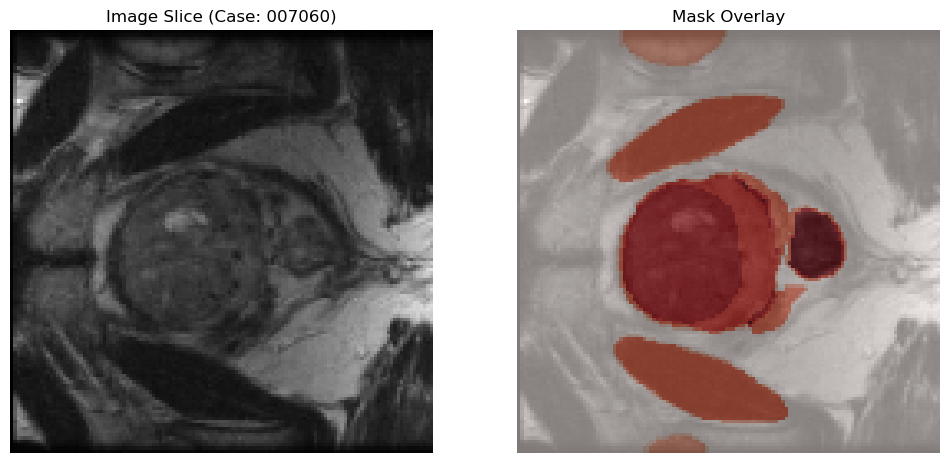


Successfully removed temporary directory: temp_integration_test_data_notebook


In [8]:
if data_zip_path.exists():
    real_dataset = SegmentationDataset(data_dir=resized_data_dir, split_file=train_split_file)
    print(f"Successfully loaded dataset from real data with {len(real_dataset)} samples.")
    
    # Get a sample from the middle of the dataset
    real_item = real_dataset[len(real_dataset) // 2]
    
    print(f"\nVisualizing sample for case: {real_item['case_id']}")
    
    # Prepare for visualization
    image_slice = real_item['image'][0, :, :, resize_dims[2] // 2].numpy()
    mask_slice = real_item['mask'][:, :, resize_dims[2] // 2].numpy()

    # Plot the image and mask slices
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(image_slice, cmap='gray')
    axs[0].set_title(f"Image Slice (Case: {real_item['case_id']})")
    axs[0].axis('off')

    axs[1].imshow(image_slice, cmap='gray')
    axs[1].imshow(mask_slice, cmap='Reds', alpha=0.5)
    axs[1].set_title(f"Mask Overlay")
    axs[1].axis('off')

    plt.show()
    
    # Clean up the integration test directory
    shutil.rmtree(integration_test_dir)
    print(f"\nSuccessfully removed temporary directory: {integration_test_dir}")